# Unified Speeches — Data Quality EDA

Checks the `data/unified_speeches.csv` for completeness, consistency, and anomalies before analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from pathlib import Path

DATA = Path('..') / 'data' / 'unified_speeches.csv'
df = pd.read_csv(DATA)
print(f"{df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(2)

1,800 rows × 9 columns


,speaker,party,year,night,timestamp,speech,word_count,source_file,source
0,Rod O'connor,Democratic,2004,1,00:01:37,Good evening. On behalf of the dedicated leade...,400,www_c_span_transcripts2004-democratic-national...,CSPAN
1,Alice Huffman,Democratic,2004,1,00:04:39,"Welcome and thank you, delegates, for coming t...",384,www_c_span_transcripts2004-democratic-national...,CSPAN


## 1. Schema & nulls

In [2]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
summary

,dtype,null_count,null_pct,n_unique
speaker,object,0,0.0,1353
party,object,0,0.0,2
year,int64,0,0.0,6
night,int64,0,0.0,4
timestamp,object,0,0.0,1692
speech,object,0,0.0,1800
word_count,int64,0,0.0,864
source_file,object,0,0.0,125
source,object,0,0.0,4


In [3]:
# Blank strings (non-null but empty)
blank = {col: (df[col].astype(str).str.strip() == '').sum() for col in df.columns}
pd.Series(blank, name='blank_string_count')

speaker        0
party          0
year           0
night          0
timestamp      0
speech         0
word_count     0
source_file    0
source         0
Name: blank_string_count, dtype: int64

## 2. Coverage: year × party

In [4]:
coverage = df.groupby(['year', 'party']).size().unstack(fill_value=0)
coverage['total'] = coverage.sum(axis=1)
coverage

party,Democratic,Republican,total
year,,,
2004,183,62,245
2008,146,69,215
2012,131,95,226
2016,241,78,319
2020,347,94,441
2024,208,146,354


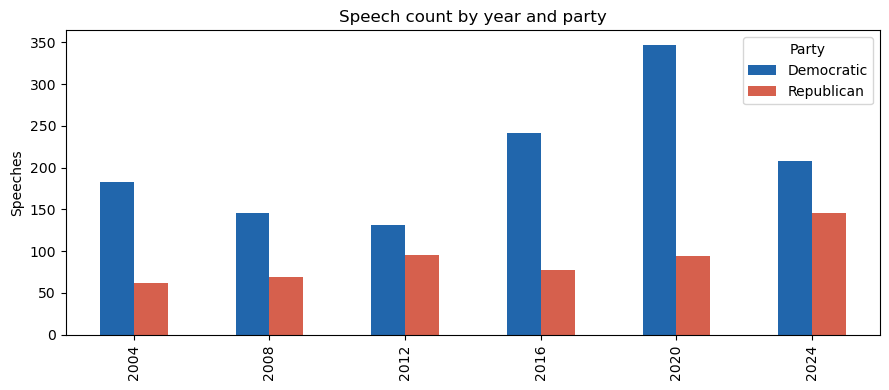

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
coverage.drop(columns='total').plot(kind='bar', ax=ax, color=['#2166ac', '#d6604d'])
ax.set_title('Speech count by year and party')
ax.set_xlabel('')
ax.set_ylabel('Speeches')
ax.legend(title='Party')
plt.tight_layout()
plt.show()

## 3. Source field consistency

In [6]:
print(df['source'].value_counts())
print()
# Cross-tab: source by year
df.groupby(['year', 'source']).size().unstack(fill_value=0)

source
CSPAN      1282
REV         496
CNN          16
YOUTUBE       6
Name: count, dtype: int64



source,CNN,CSPAN,REV,YOUTUBE
year,,,,
2004,0,245,0,0
2008,0,215,0,0
2012,0,226,0,0
2016,0,319,0,0
2020,0,0,441,0
2024,16,277,55,6


In [7]:
# Flag: 'CSPAN' vs 'C-SPAN' — are these the same source with inconsistent naming?
cspan_variants = df[df['source'].str.upper().str.replace('-','') == 'CSPAN'][['year','party','source']]
print(cspan_variants.groupby(['year','source']).size().unstack(fill_value=0))

source  CSPAN
year         
2004      245
2008      215
2012      226
2016      319
2024      277


## 4. Night distribution

In [8]:
night_tab = df.groupby(['year', 'party', 'night']).size().reset_index(name='count')
print(night_tab.to_string(index=False))

 year      party  night  count
 2004 Democratic      1     32
 2004 Democratic      2     53
 2004 Democratic      3     52
 2004 Democratic      4     46
 2004 Republican      1     30
 2004 Republican      2     15
 2004 Republican      3     12
 2004 Republican      4      5
 2008 Democratic      1     36
 2008 Democratic      2     43
 2008 Democratic      3     44
 2008 Democratic      4     23
 2008 Republican      1     10
 2008 Republican      2     16
 2008 Republican      3     19
 2008 Republican      4     24
 2012 Democratic      1     43
 2012 Democratic      2     50
 2012 Democratic      3     38
 2012 Republican      2     54
 2012 Republican      3     20
 2012 Republican      4     21
 2016 Democratic      1     53
 2016 Democratic      2     56
 2016 Democratic      3     64
 2016 Democratic      4     68
 2016 Republican      1     25
 2016 Republican      2     22
 2016 Republican      3     17
 2016 Republican      4     14
 2020 Democratic      1     58
 2020 De

In [9]:
# Any unexpected night values?
print('Night values:', sorted(df['night'].unique()))
print()
# Speeches with night == 0 or > 4
odd_nights = df[(df['night'] < 1) | (df['night'] > 4)]
print(f"{len(odd_nights)} speeches with night outside [1,4]")
if not odd_nights.empty:
    display(odd_nights[['speaker','party','year','night','source_file']].head(20))

Night values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

0 speeches with night outside [1,4]


## 5. Timestamp format

In [10]:
ts_pattern = re.compile(r'^\d{2}:\d{2}:\d{2}$')
bad_ts = df[~df['timestamp'].astype(str).str.match(r'^\d{2}:\d{2}:\d{2}$')]
print(f"{len(bad_ts)} rows with unexpected timestamp format")
if not bad_ts.empty:
    print(bad_ts['timestamp'].value_counts().head(20))

0 rows with unexpected timestamp format


## 6. Word count distribution & outliers

In [11]:
print(df['word_count'].describe().round(1))

count     1800.0
mean       508.6
std        667.9
min          2.0
25%        168.8
50%        368.0
75%        602.2
max      11938.0
Name: word_count, dtype: float64


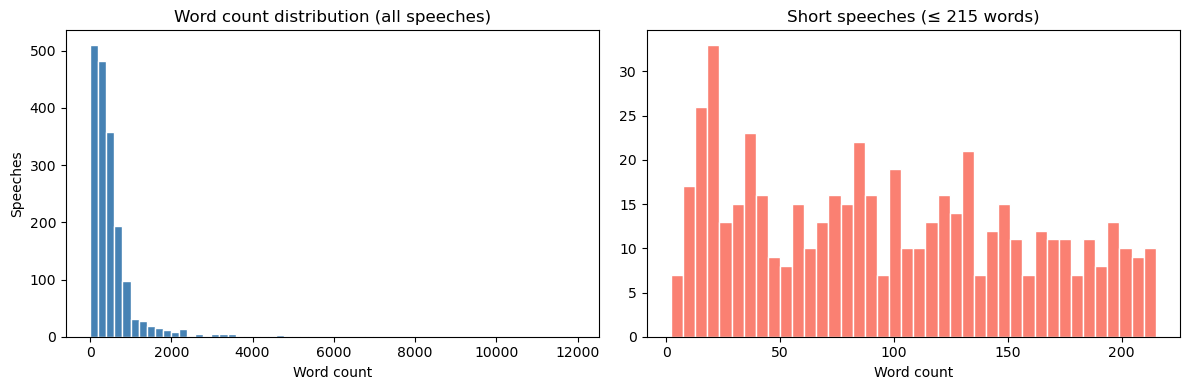

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
axes[0].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Word count distribution (all speeches)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Speeches')

# Zoom in on short speeches
axes[1].hist(df[df['word_count'] <= 215]['word_count'], bins=40, color='salmon', edgecolor='white')
axes[1].set_title('Short speeches (≤ 215 words)')
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.show()

In [13]:
# Very short speeches (possible parsing artifacts)
very_short = df[df['word_count'] < 50].sort_values('word_count')
print(f"{len(very_short)} speeches under 50 words")
if not very_short.empty:
    display(very_short[['speaker','party','year','night','word_count','speech']].assign(
        speech=lambda x: x['speech'].str[:120]
    ))

159 speeches under 50 words


,speaker,party,year,night,word_count,speech
1127,Tom Carper,Democratic,2020,2,2,Delaware passes.
1682,Michael Whatley,Republican,2024,1,3,"Senator Vance, congratulations!"
1241,Demings,Democratic,2020,3,5,Nobody is above the law.
1095,Nancy G.,Democratic,2020,2,5,The disregard for the Constitution.
1094,Micah,Democratic,2020,2,6,"The coverups, the lying, the favoritism."
...,...,...,...,...,...,...
1197,Rose G.,Democratic,2020,2,46,Biden understands how important it is to have ...
1163,Tim Ryan,Democratic,2020,2,46,…like electric vehicles or a national network ...
1231,Adamski,Democratic,2020,3,47,Us farmers can see the effects of climate chan...
1260,Molly Johnson,Democratic,2020,3,47,I remember being scared and being uncertain. W...


In [14]:
# Very long speeches (possible concatenation errors)
very_long = df[df['word_count'] > 5000].sort_values('word_count', ascending=False)
print(f"{len(very_long)} speeches over 5,000 words")
if not very_long.empty:
    display(very_long[['speaker','party','year','night','word_count','source_file']])

6 speeches over 5,000 words


,speaker,party,year,night,word_count,source_file
1797,Donald Trump,Republican,2024,4,11938,donald_trump_speaks_at_2024_republican_nationa...
1445,Donald Trump,Republican,2020,4,6859,www_rev_com_blog_transcripts2020-republican-na...
926,Hillary Clinton,Democratic,2016,4,5248,www_c_span_transcripts2016-democratic-national...
182,John Kerry,Democratic,2004,4,5203,www_c_span_transcripts2004-democratic-national...
793,Bill Clinton,Democratic,2016,2,5087,www_c_span_transcripts2016-democratic-national...
244,George W. Bush,Republican,2004,4,5079,www_c_span_transcripts2004-republican-national...


In [15]:
# Does stored word_count match actual token count?
df['computed_wc'] = df['speech'].str.split().str.len()
df['wc_delta'] = (df['word_count'] - df['computed_wc']).abs()
print("word_count vs actual token count delta:")
print(df['wc_delta'].describe().round(1))
print()
big_delta = df[df['wc_delta'] > 20]
print(f"{len(big_delta)} rows where stored word_count differs from recount by > 20")
if not big_delta.empty:
    display(big_delta[['speaker','year','party','word_count','computed_wc','wc_delta']].sort_values('wc_delta', ascending=False).head(20))
df.drop(columns=['computed_wc','wc_delta'], inplace=True)

word_count vs actual token count delta:
count    1800.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: wc_delta, dtype: float64

0 rows where stored word_count differs from recount by > 20


## 7. Word count by year and party

In [16]:
wc_stats = df.groupby(['year','party'])['word_count'].agg(['mean','median','sum']).round(0)
wc_stats

mean  median     sum
year party                            
2004 Democratic  653.0   453.0  119456
     Republican  703.0   350.0   43614
2008 Democratic  583.0   450.0   85074
     Republican  717.0   540.0   49487
2012 Democratic  634.0   570.0   83092
     Republican  703.0   394.0   66798
2016 Democratic  475.0   348.0  114515
     Republican  819.0   542.0   63847
2020 Democratic  168.0    78.0   58195
     Republican  690.0   566.0   64861
2024 Democratic  389.0   258.0   80961
     Republican  586.0   418.0   85491

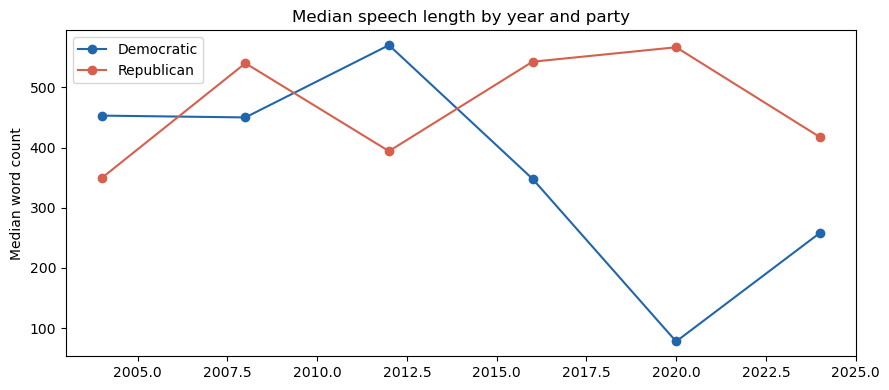

In [17]:
fig, ax = plt.subplots(figsize=(9,4))
for party, color in [('Democratic','#2166ac'),('Republican','#d6604d')]:
    sub = df[df['party']==party].groupby('year')['word_count'].median()
    ax.plot(sub.index, sub.values, marker='o', label=party, color=color)
ax.set_title('Median speech length by year and party')
ax.set_ylabel('Median word count')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Speaker-level checks

In [18]:
# Speakers appearing across both parties (possible normalization issue)
party_per_speaker = df.groupby('speaker')['party'].nunique()
both_parties = party_per_speaker[party_per_speaker > 1].index.tolist()
print(f"{len(both_parties)} speakers appear under both parties:")
if both_parties:
    display(df[df['speaker'].isin(both_parties)][['speaker','party','year','night']].sort_values('speaker'))

4 speakers appear under both parties:


,speaker,party,year,night
329,Arthur Davis,Democratic,2008,3
636,Arthur Davis,Republican,2012,2
395,Charlie Crist,Republican,2008,1
582,Charlie Crist,Democratic,2012,3
607,John Kasich,Republican,2012,2
1049,John Kasich,Democratic,2020,1
162,Joseph Lieberman,Democratic,2004,4
416,Joseph Lieberman,Republican,2008,2


In [19]:
# Speakers with many speeches in a single convention (possible parser duplication)
dup_check = df.groupby(['speaker','year','party']).size().reset_index(name='n_speeches')
many = dup_check[dup_check['n_speeches'] >= 5].sort_values('n_speeches', ascending=False)
print(f"{len(many)} speaker-year combos with ≥ 5 speeches:")
display(many.head(20))

3 speaker-year combos with ≥ 5 speeches:


,speaker,year,party,n_speeches
1168,Michael Whatley,2024,Republican,17
335,Cory Booker,2024,Democratic,7
653,Jaime Harrison,2024,Democratic,7


In [20]:
# Most prolific speakers overall
df.groupby(['speaker','party','year']).size().sort_values(ascending=False).head(20)

speaker                 party       year
Michael Whatley         Republican  2024    17
Jaime Harrison          Democratic  2024     7
Cory Booker             Democratic  2024     7
Mitch Landrieu          Democratic  2024     4
Peggy Flanagan          Democratic  2024     4
Mindy Kaling            Democratic  2024     3
Meena Harris            Democratic  2024     3
Joe Biden               Democratic  2020     3
Tony Goldwyn            Democratic  2024     3
Amy Klobuchar           Democratic  2020     3
Bennie Thompson         Democratic  2020     3
Cathy McMorris Rodgers  Republican  2012     3
Lucy McBath             Democratic  2024     2
Terry Williams          Democratic  2020     2
Minyon Moore            Democratic  2024     2
Barack Obama            Democratic  2020     2
Mitch McConnell         Republican  2008     2
Jim Roosevelt           Democratic  2020     2
Barbara Boxer           Democratic  2016     2
Pete Buttigieg          Democratic  2020     2
dtype: int64

## 9. Duplicate speech detection

In [21]:
# Exact duplicate speech text
exact_dups = df[df.duplicated(subset=['speech'], keep=False)].sort_values('speech')
print(f"{len(exact_dups)} rows share identical speech text with at least one other row")
if not exact_dups.empty:
    display(exact_dups[['speaker','party','year','night','word_count','timestamp','source_file']].head(20))

0 rows share identical speech text with at least one other row


In [22]:
# Duplicate on (speaker, year, party, night) — same segment logged twice?
key_dups = df[df.duplicated(subset=['speaker','year','party','night'], keep=False)]
print(f"{len(key_dups)} rows share (speaker, year, party, night) with another row")
if not key_dups.empty:
    display(key_dups[['speaker','party','year','night','word_count','source_file']].sort_values(
        ['speaker','year','night']).head(30))

63 rows share (speaker, year, party, night) with another row


,speaker,party,year,night,word_count,source_file
1521,Ana Navarro,Democratic,2024,2,391,https://www.c-span.org/program/campaign-2024/d...
1527,Ana Navarro,Democratic,2024,2,158,https://www.c-span.org/program/campaign-2024/d...
1534,Cory Booker,Democratic,2024,3,25,https://www.c-span.org/program/campaign-2024/d...
1536,Cory Booker,Democratic,2024,3,177,https://www.c-span.org/program/campaign-2024/d...
1548,Cory Booker,Democratic,2024,3,119,https://www.c-span.org/program/campaign-2024/d...
1555,Cory Booker,Democratic,2024,3,85,https://www.c-span.org/program/campaign-2024/d...
1559,Cory Booker,Democratic,2024,3,306,https://www.c-span.org/program/campaign-2024/d...
1560,Cory Booker,Democratic,2024,3,666,https://www.c-span.org/program/campaign-2024/d...
1572,Cory Booker,Democratic,2024,3,103,https://www.c-span.org/program/campaign-2024/d...
1767,Donald Trump Jr.,Republican,2024,3,121,https://www.c-span.org/program/campaign-2024/r...


## 10. Speech text quality

In [23]:
# Speeches that look like transcription artifacts: high ratio of uppercase, 
# lots of brackets, or no sentence-ending punctuation

def upper_ratio(text):
    letters = [c for c in text if c.isalpha()]
    return sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0

df['upper_ratio'] = df['speech'].apply(upper_ratio)
df['bracket_count'] = df['speech'].str.count(r'\[')
df['has_sentence_end'] = df['speech'].str.contains(r'[.!?]')

print("Upper-case letter ratio stats:")
print(df['upper_ratio'].describe().round(3))
print()
high_upper = df[df['upper_ratio'] > 0.4]
print(f"{len(high_upper)} speeches with >40% uppercase letters")
if not high_upper.empty:
    display(high_upper[['speaker','party','year','upper_ratio','word_count']].sort_values('upper_ratio', ascending=False).head(15))

Upper-case letter ratio stats:
count    1800.000
mean        0.037
std         0.012
min         0.005
25%         0.029
50%         0.035
75%         0.042
max         0.143
Name: upper_ratio, dtype: float64

0 speeches with >40% uppercase letters


In [24]:
# Speeches with many audience-cue brackets like [APPLAUSE], [LAUGHTER]
print("Bracket count stats:")
print(df['bracket_count'].describe().round(1))
print()
many_brackets = df[df['bracket_count'] > 20].sort_values('bracket_count', ascending=False)
print(f"{len(many_brackets)} speeches with > 20 bracketed cues")
if not many_brackets.empty:
    display(many_brackets[['speaker','party','year','bracket_count','word_count','source']].head(15))

Bracket count stats:
count    1800.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         1.0
Name: bracket_count, dtype: float64

0 speeches with > 20 bracketed cues


In [25]:
# Speeches with no sentence-ending punctuation
no_end = df[~df['has_sentence_end']]
print(f"{len(no_end)} speeches with no sentence-ending punctuation")
if not no_end.empty:
    display(no_end[['speaker','party','year','word_count','speech']].assign(
        speech=lambda x: x['speech'].str[:150]
    ))

0 speeches with no sentence-ending punctuation


In [26]:
# Clean up helper columns
df.drop(columns=['upper_ratio','bracket_count','has_sentence_end'], inplace=True)

## 11. Source file consistency

In [27]:
# How many unique source files per year/party?
sf = df.groupby(['year','party'])['source_file'].nunique().unstack(fill_value=0)
sf

party,Democratic,Republican
year,,
2004,9,5
2008,4,4
2012,3,4
2016,4,4
2020,4,4
2024,36,44


In [28]:
# Source files that contribute an unusually large or small number of speeches
sf_counts = df.groupby('source_file').size().sort_values(ascending=False)
print("Top 20 source files by speech count:")
print(sf_counts.head(20).to_string())
print()
print("Bottom 20:")
print(sf_counts.tail(20).to_string())

Top 20 source files by speech count:
source_file
www_rev_com_blog_transcriptsdemocratic-national-convention-dnc-2020-night-2-transcript.txt    140
www_rev_com_blog_transcripts2020-democratic-national-convention-dnc-night-4-transcript.txt     82
www_c_span_transcripts2016-democratic-national-convention-dnc-night-4-transcript.txt           68
www_rev_com_blog_transcriptsdemocratic-national-convention-dnc-night-3-transcript.txt          67
www_c_span_transcripts2016-democratic-national-convention-dnc-night-3-transcript.txt           64
https://www.c-span.org/program/campaign-2024/democratic-national-convention-day-4/647461       58
www_rev_com_blog_transcriptsdemocratic-national-convention-dnc-night-1-transcript.txt          58
www_c_span_transcripts2016-democratic-national-convention-dnc-night-2-transcript.txt           56
www_c_span_transcripts2016-democratic-national-convention-dnc-night-1-transcript.txt           53
https://www.c-span.org/program/campaign-2024/democratic-national-conv

In [29]:
# Source files spanning multiple years or parties (sanity check)
sf_meta = df.groupby('source_file').agg(
    years=('year', lambda x: sorted(x.unique())),
    parties=('party', lambda x: sorted(x.unique())),
    n=('speaker', 'count')
)
multi_year_sf = sf_meta[sf_meta['years'].apply(len) > 1]
print(f"{len(multi_year_sf)} source files span multiple years (should be 0):")
if not multi_year_sf.empty:
    display(multi_year_sf)

0 source files span multiple years (should be 0):


## 12. Summary of flagged issues

In [30]:
issues = []

# Source naming
if df['source'].isin(['CSPAN','C-SPAN']).any():
    variants = df[df['source'].isin(['CSPAN','C-SPAN'])]['source'].value_counts().to_dict()
    issues.append(f"SOURCE NAMING: 'CSPAN' and 'C-SPAN' both present — {variants}")

# Night range
odd_nights = df[(df['night'] < 1) | (df['night'] > 4)]
if len(odd_nights):
    issues.append(f"NIGHT RANGE: {len(odd_nights)} speeches with night outside [1,4]")

# Timestamp format
bad_ts = df[~df['timestamp'].astype(str).str.match(r'^\d{2}:\d{2}:\d{2}$')]
if len(bad_ts):
    issues.append(f"TIMESTAMP FORMAT: {len(bad_ts)} rows deviate from HH:MM:SS")

# Word count mismatch
df['computed_wc'] = df['speech'].str.split().str.len()
df['wc_delta'] = (df['word_count'] - df['computed_wc']).abs()
big_delta = df[df['wc_delta'] > 20]
if len(big_delta):
    issues.append(f"WORD COUNT MISMATCH: {len(big_delta)} rows where stored vs recomputed count differs by >20")
else:
    issues.append(f"WORD COUNT INTEGRITY: clean — stored word_count matches recomputed count for all {len(df):,} rows")
df.drop(columns=['computed_wc','wc_delta'], inplace=True)

# Very short
n_short = (df['word_count'] < 50).sum()
if n_short:
    issues.append(f"SHORT SPEECHES: {n_short} speeches under 50 words")

# Very long
n_long = (df['word_count'] > 5000).sum()
if n_long:
    issues.append(f"LONG SPEECHES: {n_long} speeches over 5,000 words")

# Both parties
party_per_speaker = df.groupby('speaker')['party'].nunique()
n_both = (party_per_speaker > 1).sum()
if n_both:
    issues.append(f"CROSS-PARTY SPEAKERS: {n_both} speaker names appear under both parties")

# Exact text dupes
n_text_dups = df.duplicated(subset=['speech'], keep=False).sum()
if n_text_dups:
    issues.append(f"DUPLICATE TEXT: {n_text_dups} rows share identical speech text")

# Key dupes
n_key_dups = df.duplicated(subset=['speaker','year','party','night'], keep=False).sum()
if n_key_dups:
    issues.append(f"DUPLICATE KEY: {n_key_dups} rows share (speaker, year, party, night)")

# Multi-year source files
sf_meta = df.groupby('source_file')['year'].nunique()
n_multi = (sf_meta > 1).sum()
if n_multi:
    issues.append(f"SOURCE FILE SPANS YEARS: {n_multi} source files cover multiple years")

print(f"{len(issues)} item(s) in summary:\n")
for i, issue in enumerate(issues, 1):
    print(f"  {i}. {issue}")

6 item(s) in summary:

  1. SOURCE NAMING: 'CSPAN' and 'C-SPAN' both present — {'CSPAN': 1282}
  2. WORD COUNT INTEGRITY: clean — stored word_count matches recomputed count for all 1,800 rows
  3. SHORT SPEECHES: 159 speeches under 50 words
  4. LONG SPEECHES: 6 speeches over 5,000 words
  5. CROSS-PARTY SPEAKERS: 4 speaker names appear under both parties
  6. DUPLICATE KEY: 63 rows share (speaker, year, party, night)
